In [1]:
%pip install --quiet phiflow
from phi.jax.flow import *
# from phi.flow import *  # If JAX is not installed. You can use phi.torch or phi.tf as well.
from tqdm.notebook import trange


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [5]:
# 1. Define the Domain (10x10 units)
domain = Box(x=10, y=10)

In [6]:
# 2. Define the Static Obstacle
# A 2x2 box centered at (5,5)
cube = Obstacle(Cuboid(center=vec(x=5, y=5), x=2, y=2))

In [7]:
# 3. Create a Grid to visualize the resolution
# We use 54x54 cells as requested in your snippet
grid_resolution = dict(x=54, y=54)

In [8]:
# Convert the mathematical shape (cube.geometry) into a Grid Mask (0s and 1s)
# This is how you "see" the grid matrix.
mask_grid = CenteredGrid(cube.geometry, extrapolation.ZERO, bounds=domain, **grid_resolution)

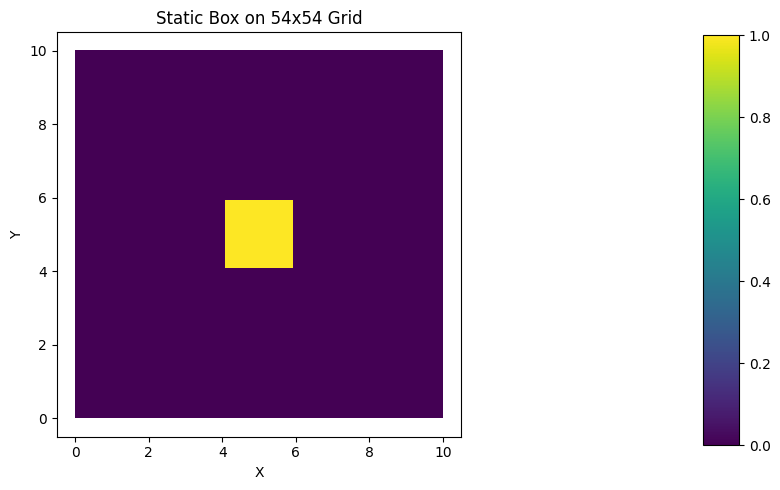

Center slice of the grid (Matrix View):
. . . . . . . . . . . . . . .
. . . . . . . . . . . . . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . X X X X X X X X X X . . .
. . . . . . . . . . . . . . .
. . . . . . . . . . . . . . .
. . . . . . . . . . . . . . .


In [22]:
# --- PLOTTING ---
import matplotlib.pyplot as plt

# Plot 1: Standard PhiFlow Plot (Vector Shape)
plot(mask_grid, title="Static Box on 54x54 Grid")
plt.show()

# --- VIEW THE MATRIX VALUES ---
# This shows the actual 0s and 1s the solver uses
print("Center slice of the grid (Matrix View):")
# We take a slice from the middle of the grid (y index 20 to 35)
matrix_slice = mask_grid.values.numpy('y,x')[20:35, 20:35]

for row in matrix_slice:
    # Print 'X' for obstacle (1.0) and '.' for empty space (0.0)
    print(" ".join(["X" if val > 0.5 else "." for val in row]))

In [19]:
%pip install --quiet phiflow matplotlib

from phi.jax.flow import *
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. GENERIC PLOTTING FUNCTION
# ==========================================
def plot_sdf_grid(sdf_grid, title="SDF Visualization"):
    """
    Takes any PhiFlow Grid containing SDF values and plots it.
    - Displays a Heatmap (Red=Inside, Blue=Outside)
    - Prints a text slice of the center values.
    """
    # Extract values as a standard numpy matrix
    values = sdf_grid.values.numpy('y,x')
    
    # --- VISUALIZATION: IMAGE ---
    plt.figure(figsize=(8, 6))
    
    # Find max value to center the colorbar at 0 (White)
    max_val = np.max(np.abs(values))
    
    # Plot: origin='lower' puts (0,0) at bottom-left
    im = plt.imshow(values, origin='lower', cmap='RdBu', vmin=-max_val, vmax=max_val)
    plt.colorbar(im, label="Signed Distance (Negative = Inside)")
    plt.title(title)
    plt.show()

    # --- VISUALIZATION: TEXT MATRIX ---
    print(f"\n--- Matrix Values (Center Slice of {title}) ---")
    print("Legend: [Negative] = Inside Object, Positive = Outside Fluid\n")
    
    # Calculate center and slice radius
    h, w = values.shape
    cy, cx = h // 2, w // 2
    r = 4 # Show 4 cells around center
    
    # Extract the slice
    matrix_slice = values[cy-r:cy+r, cx-r:cx+r]

    for row in matrix_slice:
        line_str = ""
        for val in row:
            if val <= 0:
                # Format INSIDE values with brackets
                line_str += f"[{val:5.2f}] " 
            else:
                # Format OUTSIDE values normally
                line_str += f" {val:5.2f}  "
        print(line_str)




Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


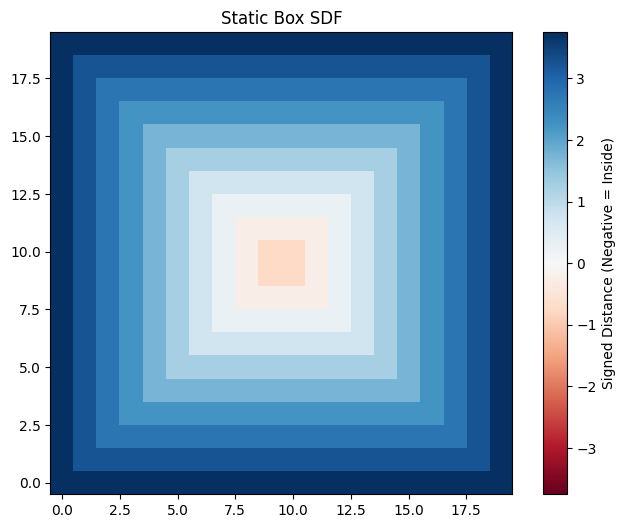


--- Matrix Values (Center Slice of Static Box SDF) ---
Legend: [Negative] = Inside Object, Positive = Outside Fluid

  0.75    0.75    0.75    0.75    0.75    0.75    0.75    0.75  
  0.75    0.25    0.25    0.25    0.25    0.25    0.25    0.75  
  0.75    0.25  [-0.25] [-0.25] [-0.25] [-0.25]   0.25    0.75  
  0.75    0.25  [-0.25] [-0.75] [-0.75] [-0.25]   0.25    0.75  
  0.75    0.25  [-0.25] [-0.75] [-0.75] [-0.25]   0.25    0.75  
  0.75    0.25  [-0.25] [-0.25] [-0.25] [-0.25]   0.25    0.75  
  0.75    0.25    0.25    0.25    0.25    0.25    0.25    0.75  
  0.75    0.75    0.75    0.75    0.75    0.75    0.75    0.75  


In [20]:
# ==========================================
# 2. YOUR SIMULATION SETUP
# ==========================================

# Define Domain
domain = Box(x=10, y=10)

# Define Obstacle (You can change this to Sphere, or Union of shapes)
obstacle = Obstacle(Cuboid(center=vec(x=5, y=5), x=2, y=2))

# Resolution for visualization (20x20 makes the text readable)
res = dict(x=20, y=20)

# Create the SDF Grid
# We pass the 'approximate_signed_distance' function to the grid
sdf_grid = CenteredGrid(obstacle.geometry.approximate_signed_distance, extrapolation.ZERO, bounds=domain, **res)

# ==========================================
# 3. RUN THE GENERIC PLOTTER
# ==========================================
plot_sdf_grid(sdf_grid, title="Static Box SDF")

In [18]:
obstacle = Obstacle(Sphere(x=5, y=5, radius=2))


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Custom Obstacle Matrix (Center Slice):
[[0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 1. 0. 0.]]


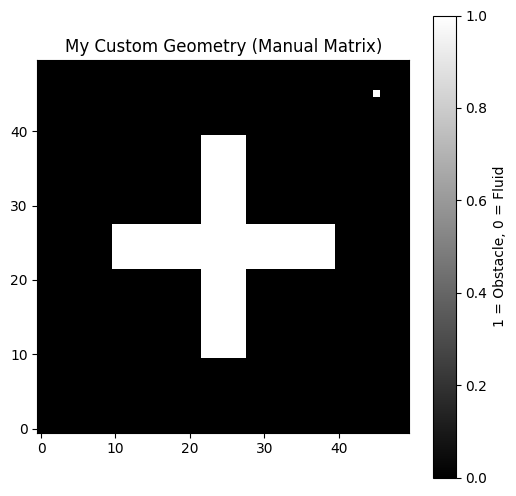

In [23]:
%pip install --quiet phiflow matplotlib

from phi.jax.flow import *
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SETUP DOMAIN ---
# We want a 50x50 grid for this example
RES_X, RES_Y = 50, 50
domain = Box(x=RES_X, y=RES_Y)

# --- 2. MAKE YOUR OWN GEOMETRY (THE "MATRIX" WAY) ---
# Create an empty numpy matrix of zeros (0 = Fluid)
# We use standard numpy, so you can use any logic you want here.
custom_matrix = np.zeros((RES_Y, RES_X))

# --- DRAW YOUR SHAPE HERE ---
# Example: Let's draw a "Cross" manually using array slicing
# Vertical bar
custom_matrix[10:40, 22:28] = 1.0  
# Horizontal bar
custom_matrix[22:28, 10:40] = 1.0

# You can even edit single pixels if you want:
custom_matrix[45, 45] = 1.0 # A single dot in the corner

# --- 3. CONVERT TO PHIFLOW GRID ---
# We convert our numpy matrix into a Phiflow "CenteredGrid".
# We explicitly tell it that the dimensions are 'y' and 'x'.
custom_obstacle_mask = CenteredGrid(
    values=math.tensor(custom_matrix, spatial('y, x')),
    extrapolation=extrapolation.ZERO,
    bounds=domain
)

# --- 4. VISUALIZE YOUR CUSTOM OBSTACLE ---
print("Custom Obstacle Matrix (Center Slice):")
# Print a small slice of the center where the cross intersection is
print(custom_matrix[20:30, 20:30])

plt.figure(figsize=(6,6))
plt.title("My Custom Geometry (Manual Matrix)")
# Plotting the raw matrix
plt.imshow(custom_matrix, origin='lower', cmap='gray')
plt.colorbar(label="1 = Obstacle, 0 = Fluid")
plt.show()

# --- HOW TO USE THIS IN SIMULATION? ---
# When you run your fluid step, instead of passing [cube], you pass this mask.
# Example (Pseudocode):
# velocity = advect.mac_cormack(velocity, velocity, dt)
# velocity, pressure = fluid.make_incompressible(velocity, obstacles=[custom_obstacle_mask])

### Make SDF from .DAT file

In [24]:
import numpy as np
from matplotlib.path import Path

def create_sdf_from_dat(filename, grid_height, grid_width, scale=1.0, offset=(0, 0)):
    """
    Reads a .dat file (X Y coordinates) and returns an SDF function 
    compatible with your FluidGrid.
    """
    
    # 1. Read coordinates from .dat file
    # Lines starting with # or text are skipped. 
    # Assumes 2 columns: x y
    coords = []
    with open(filename, 'r') as f:
        for line in f:
            try:
                parts = line.strip().split()
                if len(parts) >= 2:
                    # Parse X and Y. 
                    # Note: Airfoil .dat files are usually 0..1 range.
                    x, y = float(parts[0]), float(parts[1])
                    coords.append((x, y))
            except ValueError:
                continue # Skip header lines
    
    # Convert to numpy array
    polygon_points = np.array(coords)

    # 2. Scale and Position the Polygon on your Grid
    # We multiply by grid size (or custom scale) and add offset
    polygon_points[:, 0] = polygon_points[:, 0] * scale + offset[0] # X (usually maps to column index)
    polygon_points[:, 1] = polygon_points[:, 1] * scale + offset[1] # Y (usually maps to row index)

    # Create a Path object for fast "contains_point" checks
    path = Path(polygon_points)

    # 3. Define the SDF function
    # Your Grid calls sdf(row, col). 
    # Note: In your code: row=i (y-axis conceptually), col=j (x-axis conceptually).
    # Matplotlib Path expects (x, y). So we pass (col, row).
    def sdf(row, col):
        # Check if point is inside
        # path.contains_point returns True if inside.
        # We return -1.0 for Inside, +1.0 for Outside.
        if path.contains_point((col, row)):
            return -1.0 # Negative = Solid
        else:
            return 1.0  # Positive = Fluid
            
    return sdf

# --- OPTIONAL: TRUE DISTANCE SDF (Smoother physics) ---
# If you want better physics later, use this version. 
# It's slower to initialize but gives real distances, not just -1/+1.
from scipy.spatial import cKDTree

def create_smooth_sdf_from_dat(filename, grid_height, grid_width, scale=1.0, offset=(0, 0)):
    coords = []
    with open(filename, 'r') as f:
        for line in f:
            try:
                parts = line.strip().split()
                if len(parts) >= 2:
                    coords.append((float(parts[0]), float(parts[1])))
            except ValueError: continue
            
    points = np.array(coords)
    points[:, 0] = points[:, 0] * scale + offset[0]
    points[:, 1] = points[:, 1] * scale + offset[1]
    
    path = Path(points)
    
    # Pre-calculate tree for distance checking
    tree = cKDTree(points)
    
    def sdf(row, col):
        # 1. Check Inside/Outside
        is_inside = path.contains_point((col, row))
        
        # 2. Calculate distance to nearest boundary point
        # (This is an approximation using vertex distance)
        dist, _ = tree.query((col, row))
        
        # Return negative distance if inside, positive if outside
        return -dist if is_inside else dist

    return sdf

Created dummy file: naca0012_test.dat

Testing Grid (50x100)...


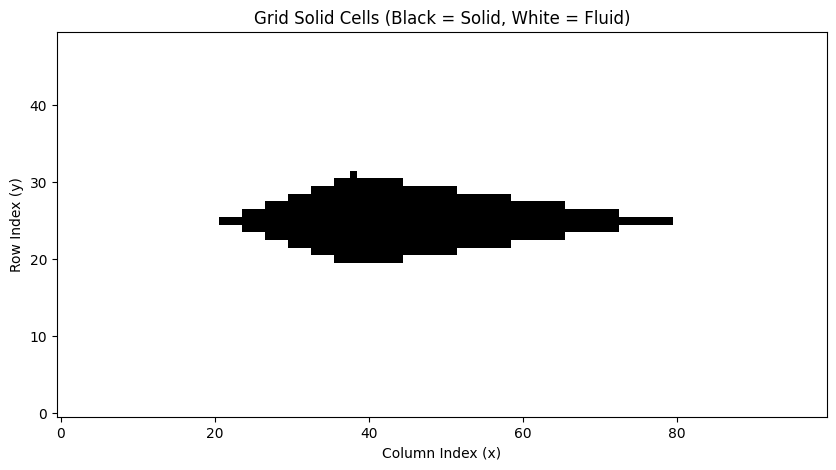

Test Complete. If you see a black shape above, the SDF function works!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

# # --- 1. SETUP: Create a dummy .dat file for testing ---
# def create_dummy_dat_file(filename="naca0012_test.dat"):
#     """Creates a simple diamond shape approximating an airfoil for testing."""
#     with open(filename, "w") as f:
#         f.write("NACA 0012 TEST SHAPE\n")
#         # Top surface
#         f.write("0.0 0.0\n")
#         f.write("0.3 0.1\n") # Thickest part
#         f.write("1.0 0.0\n")
#         # Bottom surface
#         f.write("0.3 -0.1\n")
#         f.write("0.0 0.0\n")
#     print(f"Created dummy file: {filename}")

def approximate_signed_distance(self, location: Union[Tensor, tuple]):
        """
        Computes the signed L-infinity norm (manhattan distance) from the location to the nearest side of the box.
        For an outside location `l` with the closest surface point `s`, the distance is `max(abs(l - s))`.
        For inside locations it is `-max(abs(l - s))`.

        Args:
          location: float tensor of shape (batch_size, ..., rank)

        Returns:
          float tensor of shape (*location.shape[:-1], 1).

        """
        assert not self.is_open.any, f"approximate_signed_distance not supported for open boxes"
        # ToDo this underestimates diagonally outside points
        location = self.global_to_local(location, scale=False, origin='center')
        distance = math.abs(location) - self.half_size
        distance = math.max(distance, 'vector')
        distance = math.min(distance, self.shape.instance)  # union for instance dimensions
        return distance



# --- 2. THE SDF GENERATOR (The function you need) ---
def create_sdf_from_dat(filename, scale=1.0, offset=(0, 0)):
    """
    Reads .dat file and returns a function sdf(row, col).
    Returns -1.0 if inside (Solid), 1.0 if outside (Fluid).
    """
    # Read coordinates
    coords = []
    with open(filename, 'r') as f:
        for line in f:
            try:
                parts = line.strip().split()
                if len(parts) >= 2:
                    coords.append((float(parts[0]), float(parts[1])))
            except ValueError: continue
            
    # Prepare Polygon
    points = np.array(coords)
    # Apply Scale and Offset (Transform to Grid Coordinates)
    points[:, 0] = points[:, 0] * scale + offset[0] # X
    points[:, 1] = points[:, 1] * scale + offset[1] # Y
    
    path = Path(points)
    
    # The actual SDF function your Grid will call
    def sdf(row, col):
        # Note: Grid usually does grid[row][col] -> (y, x)
        # But Matplotlib Path expects (x, y) -> (col, row)
        if path.contains_point((col, row)):
            return -1.0 # SOLID
        else:
            return 1.0  # FLUID
            
    return sdf

# --- 3. DUMMY GRID TESTER (Replaces your Class) ---
def test_grid_logic(height, width, sdf_func):
    """
    Simulates the loop inside your FluidGrid class to check if
    the SDF works correctly.
    """
    print(f"\nTesting Grid ({height}x{width})...")
    
    # Create a 2D array to store the result (0=Fluid, 1=Solid)
    # This mimics: self.grid[i][j] ... if sdf(i,j) < 0
    visual_grid = np.zeros((height, width))
    
    for i in range(height):      # Row (Y)
        for j in range(width):   # Col (X)
            
            # CALL THE SDF FUNCTION
            val = sdf_func(i, j)
            
            # If negative, mark as Solid (1) for visualization
            if val < 0:
                visual_grid[i, j] = 1 
                
    return visual_grid

# --- 4. RUN THE TEST ---
if __name__ == "__main__":
    # A. Make the file
    dat_filename = "naca0012.dat"
    # create_dummy_dat_file(dat_filename)
    
    # B. Settings
    H, W = 50, 100
    SCALE = 60.0     # Make it big enough to see
    OFFSET = (20, 25) # Shift it to the middle (x=20, y=25)
    
    # C. Create the function
    my_sdf = create_sdf_from_dat(dat_filename, scale=SCALE, offset=OFFSET)
    
    # D. Run the dummy loop
    result_grid = test_grid_logic(H, W, my_sdf)
    
    # E. Visualize
    plt.figure(figsize=(10, 5))
    plt.imshow(result_grid, origin='lower', cmap='Greys')
    plt.title("Grid Solid Cells (Black = Solid, White = Fluid)")
    plt.xlabel("Column Index (x)")
    plt.ylabel("Row Index (y)")
    plt.show()
    
    print("Test Complete. If you see a black shape above, the SDF function works!")

Generating Airfoil Geometry...
Computing SDF for entire grid...
[[63.56383167 62.92902587 62.30380323 61.68845513 61.08328001 60.48640775
  59.89406583 59.31266915 58.74254269 58.18401775]
 [62.79829852 62.15567469 61.52259338 60.89935218 60.28625628 59.68361833
  59.08733809 58.49792408 57.91977833 57.3532416 ]
 [62.03943823 61.38887111 60.74779911 60.11652598 59.49536366 58.88463209
  58.28465919 57.68900694 57.10267176 56.52794638]
 [61.2874987  60.62886356 59.97966903 59.34022494 58.7108499  58.09187117
  57.48362459 56.88616635 56.29146935 55.70837569]
 [60.54273777 59.87591082 59.21846246 58.57070852 57.93297417 57.30559394
  56.68891158 56.08328001 55.48643007 54.89478593]
 [59.80542364 59.1302824  58.46444985 57.80824765 57.16200746 56.52607095
  55.90078977 55.28652545 54.68364926 54.08744699]
 [59.07583513 58.39225887 57.71791313 57.05312521 56.3982331  55.7535855
  55.11954187 54.49647233 53.88475755 53.2847886 ]
 [58.35426202 57.66213226 56.97914615 56.30563645 55.64194727 

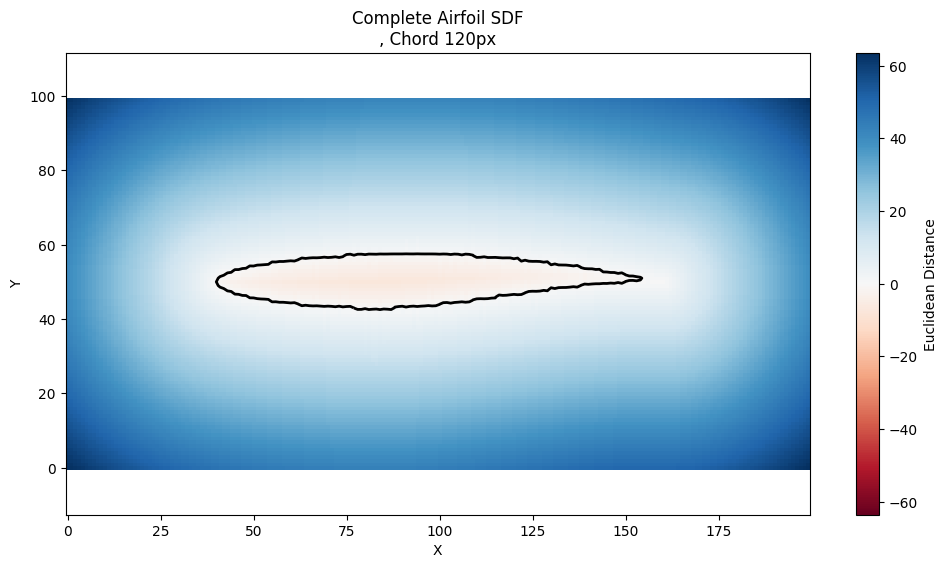

Done.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from matplotlib.path import Path





# ---------------- SDF QUERY ----------------

def compute_sdf_at_point(x, y, path, kdtree):
    # Nearest surface distance
    dist, _ = kdtree.query([x, y], k=1)

    # Inside / outside test
    is_inside = path.contains_point((x, y))

    return -dist if is_inside else dist


# ---------------- AIRFOIL HELPERS ----------------

def load_dat_file(filename):
    coords = []
    with open(filename, "r") as f:
        for line in f:
            try:
                parts = line.strip().split()
                if len(parts) >= 2:
                    coords.append((float(parts[0]), float(parts[1])))
            except ValueError:
                pass
    return coords


# ---------------- MAIN ----------------

if __name__ == "__main__":
    # Grid
    H, W = 100, 200
    grid_sdf = np.zeros((H, W))

    # Load airfoil
    print("Generating Airfoil Geometry...")
    coords = load_dat_file("RAE2822.dat")

        # 1. Load points
    points = np.array(coords)

    # 2. Scale
    chord_length = 120.0
    points *= chord_length

    # 3. Translate
    offset = (40, 50)
    points[:, 0] += offset[0]
    points[:, 1] += offset[1]

    # 4. Acceleration structures
    path = Path(points)
    kdtree = cKDTree(points)


    # Compute SDF
    print("Computing SDF for entire grid...")
    for row in range(H):
        for col in range(W):
            grid_sdf[row, col] = compute_sdf_at_point(col, row, path, kdtree)


    print(grid_sdf[:10, :10])
    # Visualize
    plt.figure(figsize=(12, 6))
    limit = np.max(np.abs(grid_sdf))

    plt.imshow(
        grid_sdf,
        origin="lower",
        cmap="RdBu",
        vmin=-limit,
        vmax=limit
    )
    plt.colorbar(label="Euclidean Distance")
    plt.contour(grid_sdf, levels=[0], colors="black", linewidths=2)

    plt.title("Complete Airfoil SDF\n, Chord 120px")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.axis("equal")
    plt.show()

    print("Done.")
